findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: 

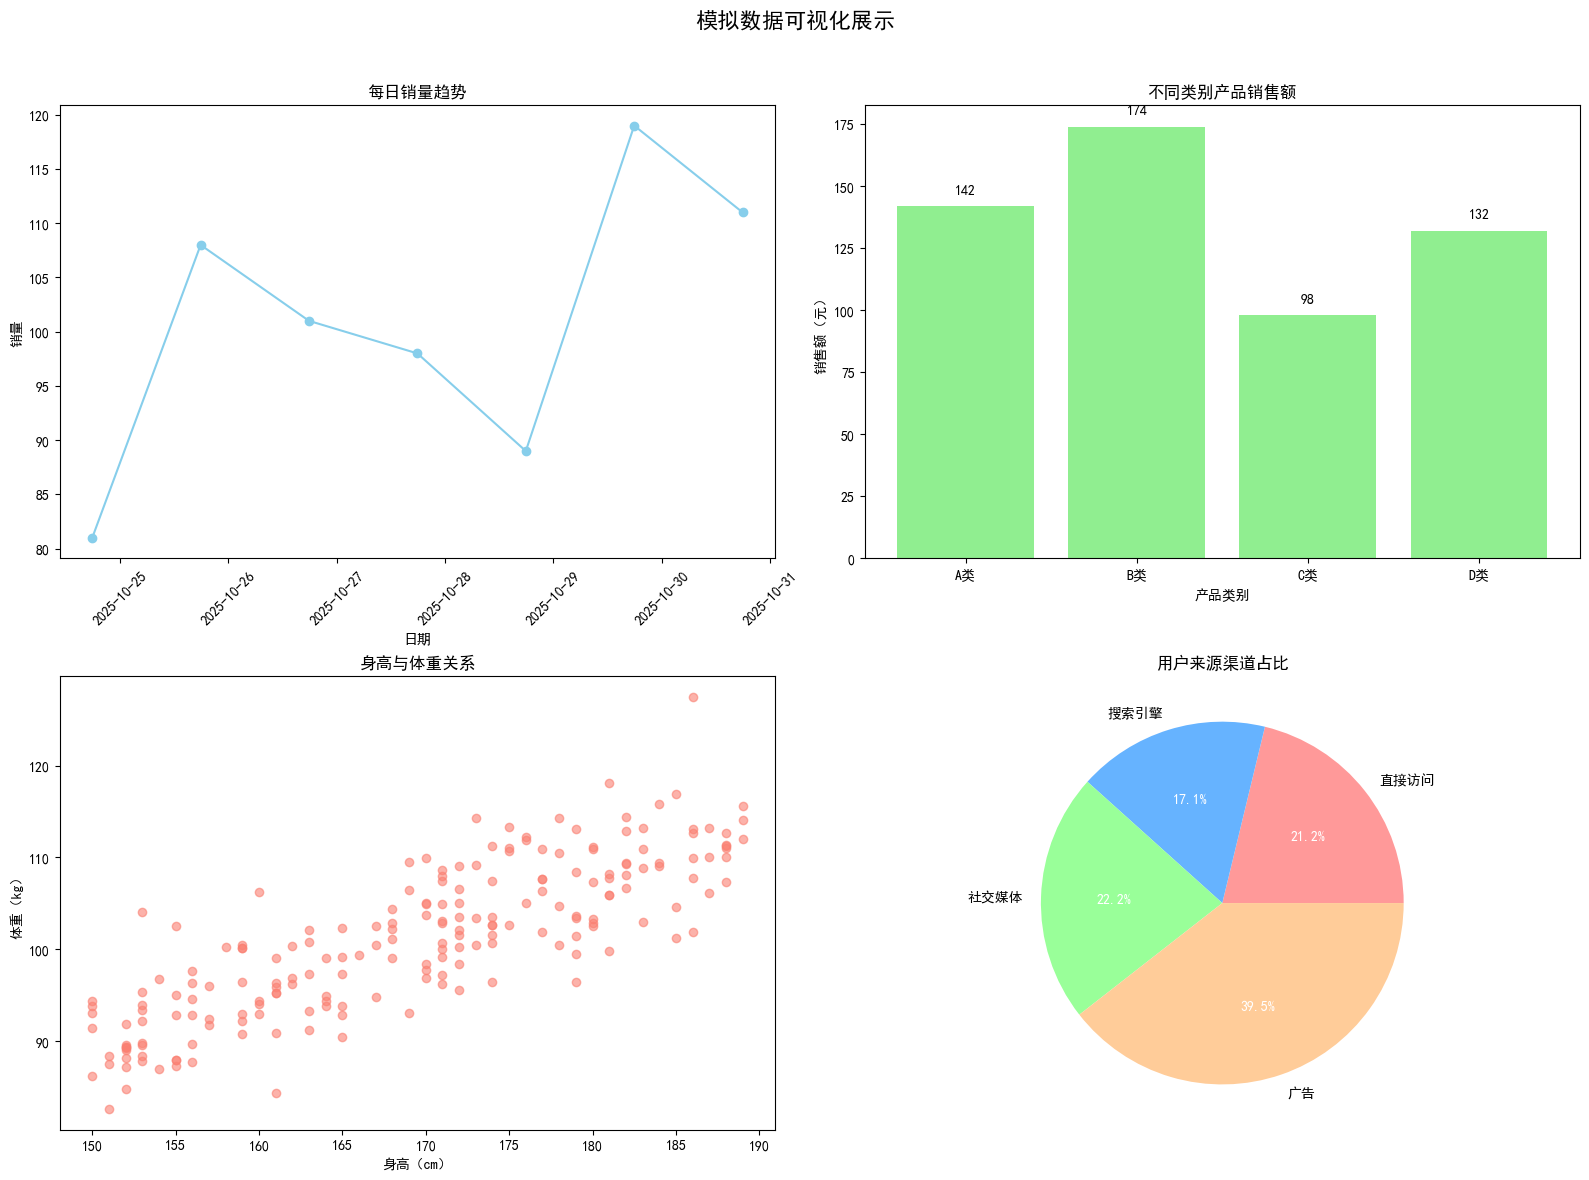

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# 设置中文显示
plt.rcParams["font.family"] = ["SimHei", "WenQuanYi Micro Hei", "Heiti TC"]
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题


def mock_time_series_data(days=7, base=100,波动范围=20):
    """生成时间序列数据（如每日销量）"""
    dates = [datetime.now() - timedelta(days=i) for i in range(days)][::-1]  # 最近days天
    values = [base + np.random.randint(-波动范围, 波动范围+1) for _ in range(days)]
    return pd.DataFrame({'日期': dates, '销量': values})


def mock_category_data(categories=['A类', 'B类', 'C类', 'D类'], min_val=50, max_val=200):
    """生成分类数据（如不同产品销售额）"""
    values = [np.random.randint(min_val, max_val) for _ in categories]
    return pd.DataFrame({'类别': categories, '销售额': values})


def mock_distribution_data(n=200, height_range=(150, 190)):
    """生成分布数据（如身高与体重的关系）"""
    heights = np.random.randint(*height_range, size=n)
    # 体重与身高正相关，加随机波动
    weights = 0.6 * heights + np.random.normal(0, 5, size=n)
    return pd.DataFrame({'身高': heights, '体重': weights})


def mock_proportion_data(categories=['直接访问', '搜索引擎', '社交媒体', '广告']):
    """生成比例数据（如用户来源占比）"""
    proportions = np.random.rand(len(categories))
    proportions = proportions / proportions.sum()  # 归一化
    return pd.DataFrame({'渠道': categories, '占比': proportions})


def plot_all_charts():
    """绘制所有图表"""
    # 创建画布和子图
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('模拟数据可视化展示', fontsize=16)

    # 1. 折线图 - 时间序列数据
    ts_data = mock_time_series_data()
    axes[0, 0].plot(ts_data['日期'], ts_data['销量'], 'o-', color='skyblue')
    axes[0, 0].set_title('每日销量趋势')
    axes[0, 0].set_xlabel('日期')
    axes[0, 0].set_ylabel('销量')
    axes[0, 0].tick_params(axis='x', rotation=45)  # 日期旋转45度

    # 2. 柱状图 - 分类数据
    cat_data = mock_category_data()
    axes[0, 1].bar(cat_data['类别'], cat_data['销售额'], color='lightgreen')
    axes[0, 1].set_title('不同类别产品销售额')
    axes[0, 1].set_xlabel('产品类别')
    axes[0, 1].set_ylabel('销售额（元）')
    # 在柱子上标注数值
    for i, v in enumerate(cat_data['销售额']):
        axes[0, 1].text(i, v + 5, str(v), ha='center')

    # 3. 散点图 - 分布数据
    dist_data = mock_distribution_data()
    axes[1, 0].scatter(dist_data['身高'], dist_data['体重'], alpha=0.6, color='salmon')
    axes[1, 0].set_title('身高与体重关系')
    axes[1, 0].set_xlabel('身高（cm）')
    axes[1, 0].set_ylabel('体重（kg）')

    # 4. 饼图 - 比例数据
    prop_data = mock_proportion_data()
    wedges, texts, autotexts = axes[1, 1].pie(
        prop_data['占比'], 
        labels=prop_data['渠道'],
        autopct='%1.1f%%',
        colors=['#ff9999','#66b3ff','#99ff99','#ffcc99']
    )
    axes[1, 1].set_title('用户来源渠道占比')
    # 设置百分比文本格式
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_weight('bold')

    # 调整布局
    plt.tight_layout()
    plt.subplots_adjust(top=0.9)  # 调整标题位置
    plt.show()


if __name__ == '__main__':
    # 生成并展示所有图表
    plot_all_charts()